# Quantum Circuit Born Machines on Bars and Stripes

A 4-qubit generative model on a **CPU simulator**. We train a parameterized circuit so that measuring it in the computational basis reproduces the 2×2 Bars-and-Stripes (BAS) distribution.

**Walkthrough:** problem → what a QCBM is → BAS → circuit → training → results.

Hardware is out of scope. 4×4 BAS (16 qubits) is noted at the end as an optional extension.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pennylane as qml
import torch
from IPython.display import Image, display

for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / "src").is_dir():
        ROOT = candidate.resolve()
        break
else:
    raise FileNotFoundError("Could not find the project src/ directory")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.bas import bitstring, target_distribution
from src.plots import (
    save_circuit_diagram,
    save_loss_curve,
    save_model_samples,
    save_probability_comparison,
    save_target_patterns,
)
from src.qcbm import QCBM, evaluate, sample_bitstrings, train_qcbm

FIGURES = ROOT / "figures"
FIGURES.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 120

print("PennyLane", qml.__version__, "| torch", torch.__version__)
print("figures ->", FIGURES)


PennyLane 0.45.1 | torch 2.6.0+cu124
figures -> /workspace/figures


## 1. The problem

A generative model learns a distribution $P(x)$ and then *draws new* $x$. In this notebook each $x$ is a 2×2 black-and-white image, stored as a 4-bit string.

There are 16 possible images and only **six** legal Bars-and-Stripes patterns. The target $\pi(x)$ is uniform on those six strings and zero elsewhere. Success means:

1. almost all of the model's probability mass sits on the legal support, and
2. the six legal probabilities are close to $1/6$.

The dataset is a toy. The *job* — fit a discrete distribution over bitstrings and score validity — is the same job that shows up when $x$ is a molecular fingerprint or a fragment-occupancy vector. Section 7 keeps that analogy honest.


## 2. What is a QCBM?

A **Quantum Circuit Born Machine** ([Liu & Wang, 2018](https://doi.org/10.1103/PhysRevA.98.062324); [Benedetti et al., 2019](https://doi.org/10.1038/s41534-019-0157-8)) is a generative model whose probabilities come from the Born rule.

1. Start from $|0\rangle^{\otimes n}$.
2. Apply a parameterized circuit $U(\theta)$ to prepare $|\psi_\theta\rangle = U(\theta)|0\rangle^{\otimes n}$.
3. Measure in the computational basis. The probability of bitstring $x$ is

$$
p_\theta(x) = \lvert\langle x \mid \psi_\theta \rangle\rvert^2.
$$

Training adjusts $\theta$ so that $p_\theta$ matches the data distribution $\pi$.

On **4 qubits** a statevector simulator returns the exact 16-outcome vector, so we can minimize the Kullback–Leibler divergence

$$
\mathrm{KL}(\pi \,\|\, p_\theta) = \sum_x \pi(x)\,\log\frac{\pi(x)}{p_\theta(x)}
$$

with ordinary backpropagation. That is the loss used below. On larger registers you typically cannot materialize $p_\theta(x)$ and would switch to a sample-based loss such as maximum mean discrepancy (MMD) — the route taken in the [PennyLane QCBM demo](https://pennylane.ai/qml/demos/tutorial_qcbm).


## 3. Bars and Stripes, briefly

An $n \times n$ image is a BAS pattern if **every row is uniform** (a bar) or **every column is uniform** (a stripe). All-zero and all-one belong to both families, so the unique support has size $2^{n+1}-2$.

| Grid | Qubits | Valid patterns | Hilbert space |
| --- | ---: | ---: | ---: |
| 2×2 (this notebook) | 4 | 6 | 16 |
| 3×3 (common demo) | 9 | 14 | 512 |
| 4×4 (optional extension) | 16 | 30 | 65 536 |

2×2 is the right default for a laptop: exact probabilities, fast Adam steps, and figures that are easy to read.


6 valid 2x2 patterns  (uniform pi = 0.1667)
  0000   grid=[[0, 0], [0, 0]]
  1010   grid=[[1, 0], [1, 0]]
  0101   grid=[[0, 1], [0, 1]]
  1100   grid=[[1, 1], [0, 0]]
  0011   grid=[[0, 0], [1, 1]]
  1111   grid=[[1, 1], [1, 1]]


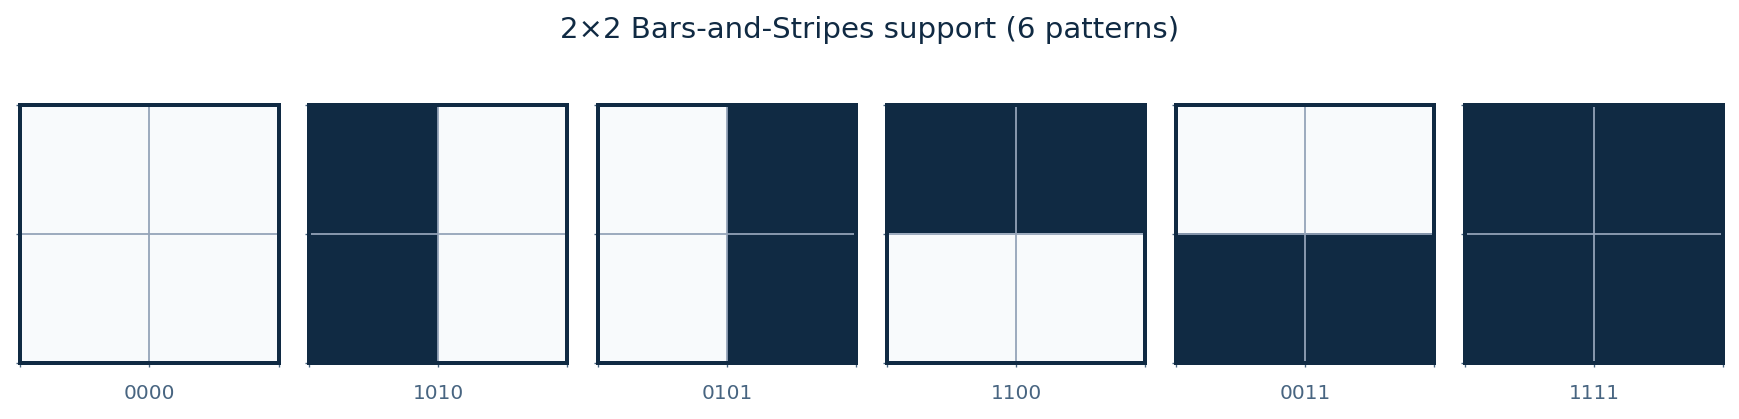

In [2]:
N = 2
N_QUBITS = N * N
patterns, valid_indices, target_probs = target_distribution(N)

print(f"{len(patterns)} valid {N}x{N} patterns  (uniform pi = {1 / len(patterns):.4f})")
for pattern, idx in zip(patterns, valid_indices):
    print(f"  {bitstring(int(idx), N_QUBITS)}   grid={pattern.reshape(N, N).tolist()}")

path = save_target_patterns(patterns, N, FIGURES / "target_bas_patterns.png")
display(Image(filename=str(path)))


## 4. Circuit

The ansatz is PennyLane's `StronglyEntanglingLayers`: each layer applies a general single-qubit rotation on every wire, then a ring of CNOTs. Four layers on four qubits is 48 real parameters — enough to fit six modes, small enough to train in seconds on CPU.

The QNode uses PennyLane's PyTorch interface and `diff_method="backprop"` because `default.qubit` is a differentiable statevector simulator.


<QNode: device='<default.qubit device (wires=4) at 0x7f8f08cf0860>', interface='torch', diff_method='backprop', shots='Shots(total=None)'>
weight shape (4, 4, 3) -> 48 parameters
0: ─╭StronglyEntanglingLayers(M0)─┤ ╭Probs
1: ─├StronglyEntanglingLayers(M0)─┤ ├Probs
2: ─├StronglyEntanglingLayers(M0)─┤ ├Probs
3: ─╰StronglyEntanglingLayers(M0)─┤ ╰Probs

M0 = 
tensor([[[3.9276, 5.6374, 4.8738],
         [1.4150, 1.8860, 5.4887],
         [0.0331, 5.1599, 5.0081],
         [2.9401, 1.9040, 1.7494]],

        [[1.6014, 2.7965, 3.1702],
         [3.4777, 6.2549, 4.9804],
         [3.9093, 6.2138, 1.3528],
         [1.0066, 3.8487, 0.2761]],

        [[0.2242, 3.2351, 2.9293],
         [5.7627, 3.9535, 3.2303],
         [3.1219, 1.5552, 0.0741],
         [1.2089, 4.3482, 1.2604]],

        [[2.3219, 0.0235, 5.2153],
         [0.9705, 1.6814, 5.5313],
         [3.2031, 5.3228, 4.0195],
         [4.6607, 0.5749, 3.4001]]], dtype=torch.float64)


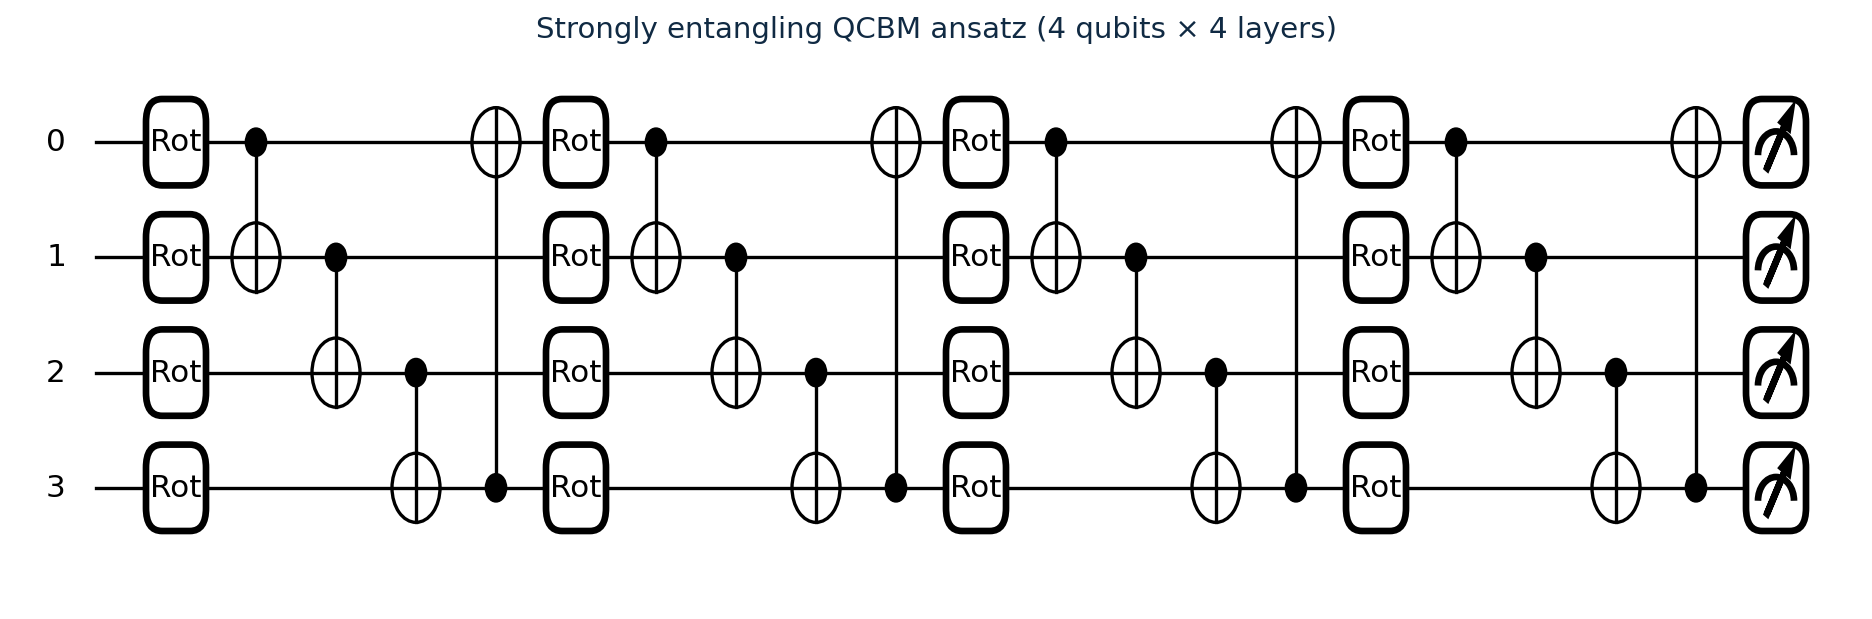

In [3]:
SEED = 7
N_LAYERS = 4
torch.manual_seed(SEED)

model = QCBM(n_qubits=N_QUBITS, n_layers=N_LAYERS, seed=SEED)
print(model.circuit)
print("weight shape", tuple(model.weights.shape), "->", model.weights.numel(), "parameters")
print(qml.draw(model.circuit)(model.weights.detach()))

circuit_path = save_circuit_diagram(model.circuit, model.weights.detach(), FIGURES / "circuit.png")
display(Image(filename=str(circuit_path)))


## 5. Training

Because the simulator returns the exact Born vector, the training loop is ordinary PyTorch:

1. Forward: `qml.probs` → $p_\theta$.
2. Loss: $\mathrm{KL}(\pi \,\|\, p_\theta)$.
3. Backward through the statevector, then `Adam` on the rotation angles.

We also log **validity mass** $\sum_{x \in \mathrm{BAS}} p_\theta(x)$ — the probability that a single shot is a legal bar or stripe.


In [4]:
STEPS = 160
LR = 0.08

history = train_qcbm(
    model,
    target_probs,
    valid_indices,
    steps=STEPS,
    lr=LR,
    log_every=20,
)

model_probs = model.probabilities().detach().cpu().numpy()
metrics = evaluate(model_probs, target_probs, valid_indices, N_QUBITS)
print("\nfinal metrics")
for key in ("kl", "total_variation", "validity_mass"):
    print(f"  {key:18s} {metrics[key]:.4f}")


step   0  KL=1.3241  P(valid)=0.670


step  20  KL=0.0770  P(valid)=0.938


step  40  KL=0.0091  P(valid)=0.993


step  60  KL=0.0012  P(valid)=0.999


step  80  KL=0.0001  P(valid)=1.000


step 100  KL=0.0000  P(valid)=1.000


step 120  KL=0.0000  P(valid)=1.000


step 140  KL=0.0000  P(valid)=1.000


step 159  KL=0.0000  P(valid)=1.000

final metrics
  kl                 0.0000
  total_variation    0.0001
  validity_mass      1.0000


## 6. Results

Three figures: the training curve, the 16-bin histogram against the target, and fresh samples from $p_\theta$. Green frames are valid BAS; red frames are not.


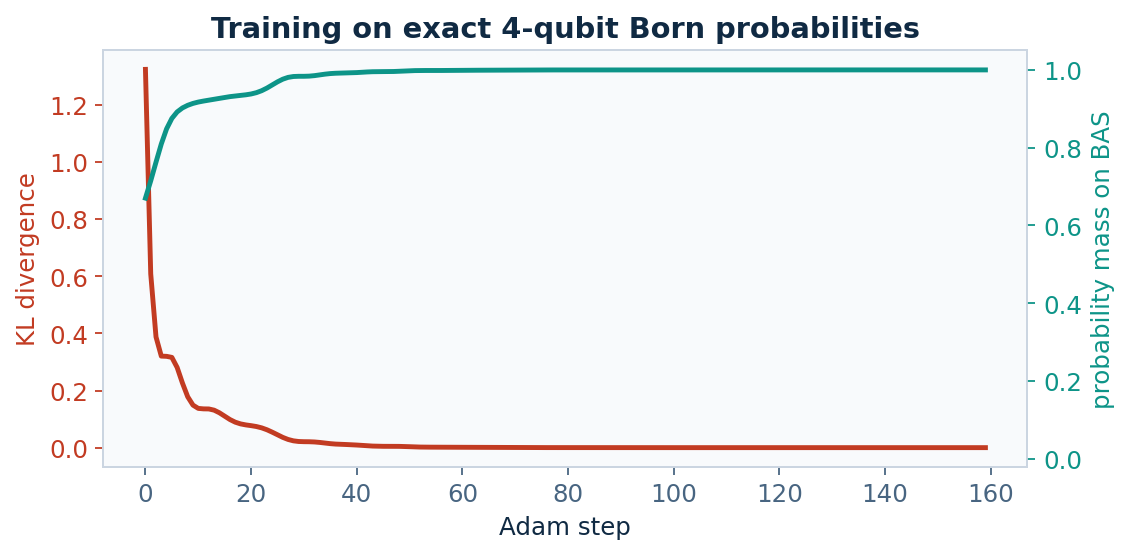

In [5]:
loss_path = save_loss_curve(history.losses, history.validity, FIGURES / "training_loss.png")
display(Image(filename=str(loss_path)))


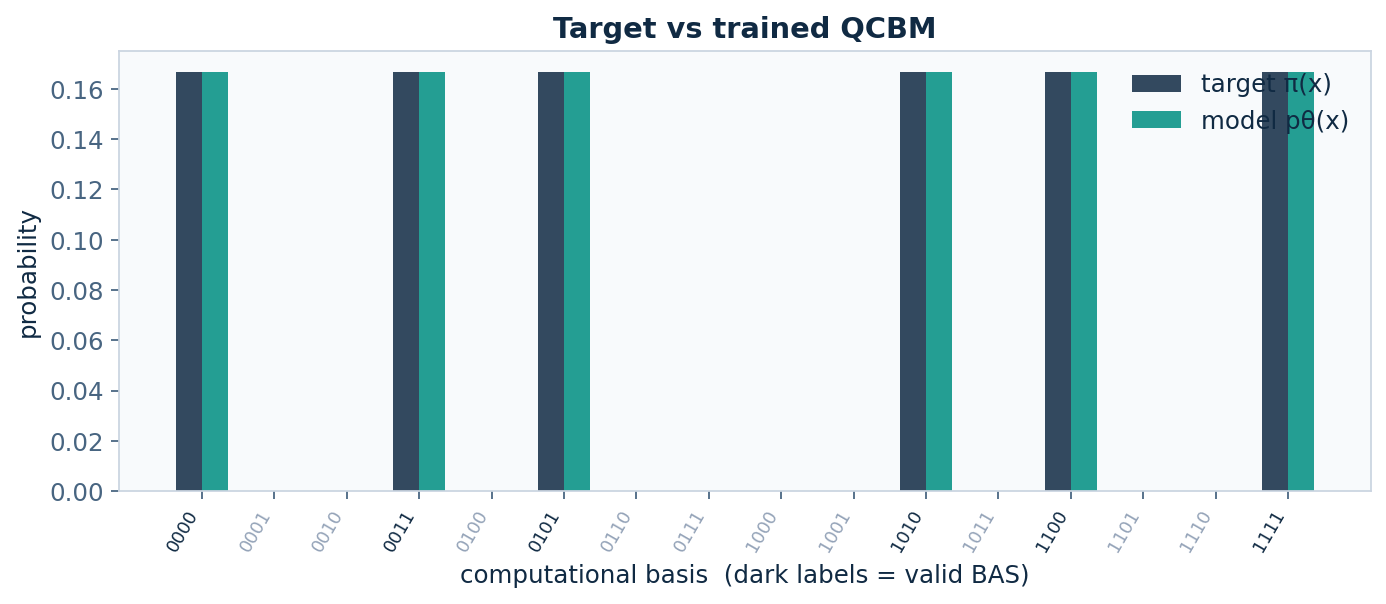

pattern   target    model
  0000    0.167    0.167
  1010    0.167    0.167
  0101    0.167    0.167
  1100    0.167    0.167
  0011    0.167    0.167
  1111    0.167    0.167


In [6]:
hist_path = save_probability_comparison(
    target_probs,
    model_probs,
    valid_indices,
    N_QUBITS,
    FIGURES / "probability_comparison.png",
)
display(Image(filename=str(hist_path)))

print("pattern   target    model")
for bits, pi, ptheta in metrics["valid_pattern_probs"]:
    print(f"  {bits}   {pi:6.3f}   {ptheta:6.3f}")


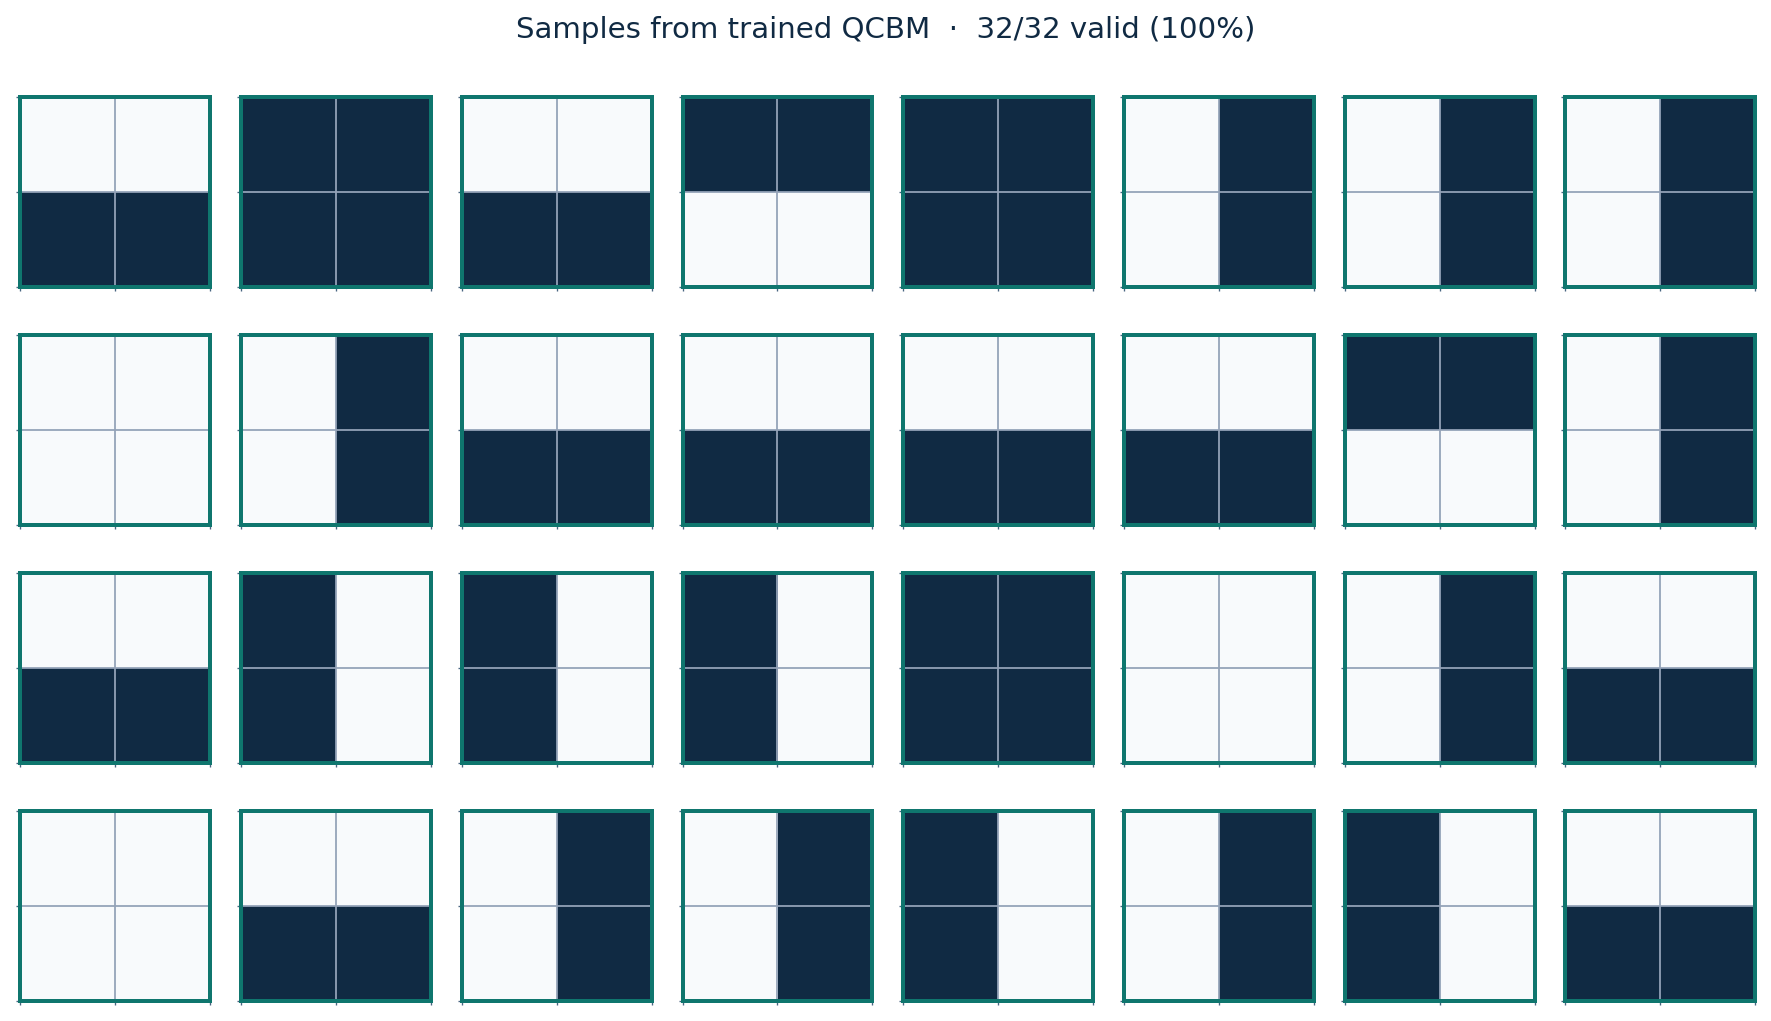

In [7]:
samples = sample_bitstrings(model_probs, n_samples=32, seed=SEED + 1)
sample_path = save_model_samples(samples, valid_indices, N, FIGURES / "model_samples.png")
display(Image(filename=str(sample_path)))


## 7. Why this maps (carefully) to molecular binary distributions

A surprising amount of early molecular design is generative modeling over **bit vectors**: fragment present / absent, hashed fingerprint bits, discretized descriptors. The abstract task is identical to BAS — learn $P(x)$ on a discrete support, then ask how often a sample is chemically (here, geometrically) valid.

That is the whole analogy. This notebook is **not**:

- a claim that QCBMs outperform VAEs, flows, or diffusion models on molecules,
- a replacement for docking, FEP, or a foundation model, or
- evidence of near-term quantum advantage.

Four simulated qubits cannot encode a drug-like molecule. Classical generative chemistry is the practical stack. The transferable piece is the workflow: define a binary support, train a generative model, and report validity plus distribution match.


## 8. Optional extension: 4×4 BAS

A 4×4 grid uses **16 qubits** and 30 valid patterns. The statevector has 65 536 amplitudes — still simulable, but exact KL plus backpropagation is much heavier, and a hardware-efficient ansatz needs more depth to place 30 modes.

If you try it:

- keep `default.qubit` (still CPU, no hardware),
- expect minutes rather than seconds,
- prefer a sample-based loss (MMD with an RBF kernel) over materializing $p_\theta$,
- score the same two numbers: validity mass and total variation on the 30-pattern support.

This repository stays on 2×2 so the notebook stays a reliable, readable portfolio piece.


## References

1. Liu, J.-G. & Wang, L. Differentiable learning of quantum circuit Born machines. *Phys. Rev. A* **98**, 062324 (2018).
2. Benedetti, M. *et al.* A generative modeling approach for benchmarking and training shallow quantum circuits. *npj Quantum Inf.* **5**, 45 (2019).
3. PennyLane. [Quantum Circuit Born Machines](https://pennylane.ai/qml/demos/tutorial_qcbm).
